# Load feature data

In [193]:
import pandas as pd
import matplotlib.pyplot as plt

# load data from weather_features.csv

df = pd.read_csv(
    './weather_features.csv',
    parse_dates=['last_updated']
)
df.shape

(144229, 86)

In [194]:
df.dtypes.value_counts()

int64             60
float64           25
datetime64[us]     1
Name: count, dtype: int64

# Time and Temperature Modelling

- Target: Daily global average temperature

## Time Series Modelling

- Temperature forecasting with only date

In [195]:
daily = (
    df.groupby(df['last_updated'].dt.date)
      ['temperature_celsius']
      .mean()
      .reset_index()
)

daily.columns = ['date', 'temperature']
daily['date'] = pd.to_datetime(daily['date'])

# sort by date
daily = daily.sort_values('date').reset_index(drop=True)

daily.head()

,date,temperature
0,2024-05-16,23.767196
1,2024-05-17,24.451648
2,2024-05-18,25.355610
3,2024-05-19,25.270103
4,2024-05-20,25.430769


In [196]:
train_size = int(len(daily) * 0.8)

train = daily.iloc[:train_size]
test  = daily.iloc[train_size:]

In [197]:
# Common imports

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 7 day Moving Average Forecast

In [198]:
history = train['temperature'].tolist()

pred_ma7 = []

for i in range(len(test)):
    forecast = sum(history[-7:]) / 7
    pred_ma7.append(forecast)
    history.append(test['temperature'].iloc[i])

In [199]:
mae_ma7 = mean_absolute_error(test['temperature'], pred_ma7)
mse_ma7 = mean_squared_error(test['temperature'], pred_ma7)
rmse_ma7 = mse_ma7 ** 0.5
r2_ma7 = r2_score(test['temperature'], pred_ma7)

print(f'MAE  : {mae_ma7:.3f}')
print(f'RMSE : {rmse_ma7:.3f}')
print(f'R²   : {r2_ma7:.3f}')

MAE  : 0.520
RMSE : 1.068
R²   : 0.843


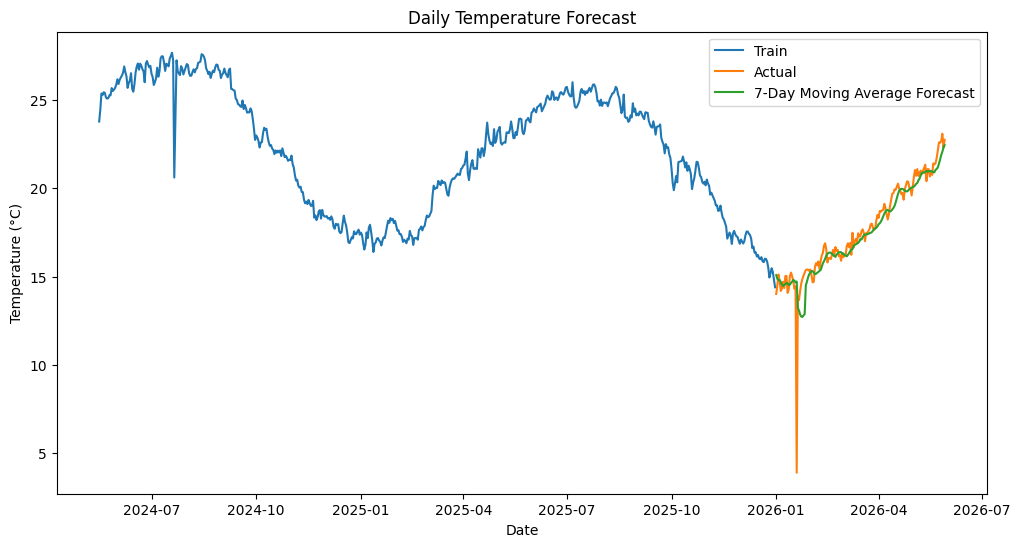

In [200]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_ma7, label='7-Day Moving Average Forecast')

plt.title('Daily Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.show()

### 3 day Moving Average Forecast

In [201]:
history = train['temperature'].tolist()
pred_ma3 = []

for _ in range(len(test)):
    forecast = sum(history[-3:]) / 3
    pred_ma3.append(forecast)
    history.append(test['temperature'].iloc[len(pred_ma3)-1])

In [202]:
mae_ma3 = mean_absolute_error(test['temperature'], pred_ma3)
mse_ma3 = mean_squared_error(test['temperature'], pred_ma3)
rmse_ma3 = mse_ma3 ** 0.5
r2_ma3 = r2_score(test['temperature'], pred_ma3)

print(f'MAE  : {mae_ma3:.3f}')
print(f'RMSE : {rmse_ma3:.3f}')
print(f'R²   : {r2_ma3:.3f}')

MAE  : 0.458
RMSE : 1.060
R²   : 0.845


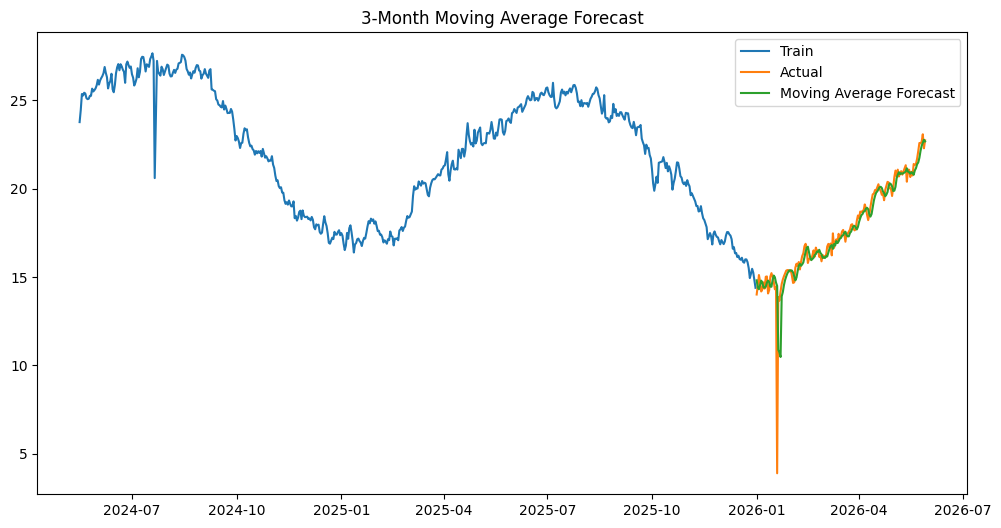

In [203]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_ma3, label='Moving Average Forecast')

plt.legend()
plt.title('3-Month Moving Average Forecast')

plt.show()

### ARIMA

In [204]:
train_size = int(len(daily) * 0.8)

train = daily[:train_size]
test  = daily[train_size:]

In [205]:
train.dtypes

date           datetime64[s]
temperature          float64
dtype: object

In [206]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train['temperature'],
    order=(1,0,1)
)

model_fit = model.fit()

In [207]:
pred_arima = model_fit.forecast(
    steps=len(test)
)

In [208]:
mae_arima = mean_absolute_error(test['temperature'], pred_arima)
mse_arima = mean_squared_error(test['temperature'], pred_arima)
rmse_arima = mse_arima ** 0.5
r2_arima = r2_score(test['temperature'], pred_arima)

print(f'MAE  : {mae_arima:.3f}')
print(f'RMSE : {rmse_arima:.3f}')
print(f'R²   : {r2_arima:.3f}')

MAE  : 2.374
RMSE : 3.080
R²   : -0.310


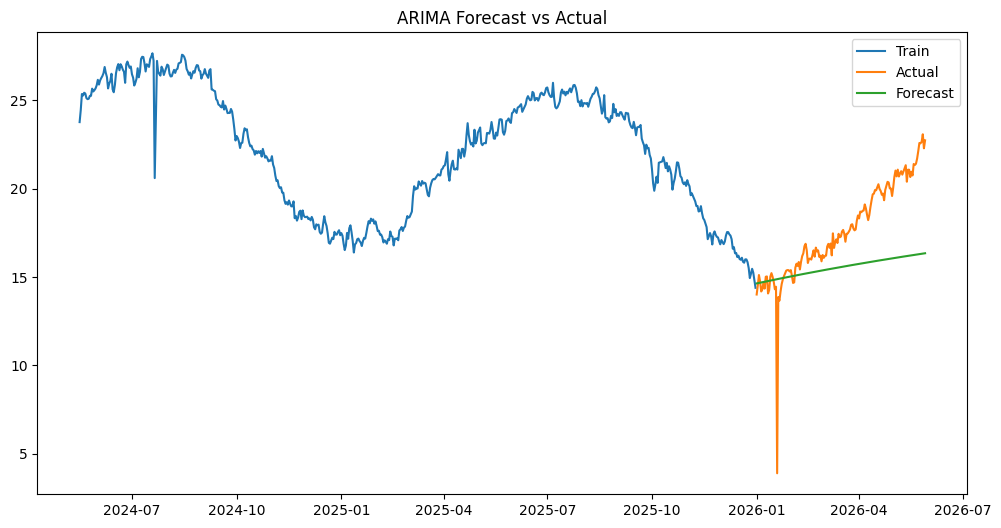

In [209]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_arima, label='Forecast')

plt.legend()
plt.title('ARIMA Forecast vs Actual')

plt.show()

### Prophet

In [210]:
from prophet import Prophet

prophet_df = daily[['date', 'temperature']].copy()

prophet_df = prophet_df.rename(columns={
    'date': 'ds',
    'temperature': 'y'
})

train_size = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=True
)

model.fit(train_prophet)

future = test_prophet[['ds']]

forecast = model.predict(future)

y_true = test_prophet['y'].values
pred_prophet = forecast['yhat'].values

mae_prophet = mean_absolute_error(y_true, pred_prophet)
mse_prophet = mean_squared_error(y_true, pred_prophet)
rmse_prophet = mse_prophet ** 0.5
r2_prophet = r2_score(y_true, pred_prophet)

print(f'MAE  : {mae_prophet:.3f}')
print(f'RMSE : {rmse_prophet:.3f}')
print(f'R²   : {r2_prophet:.3f}')

17:28:35 - cmdstanpy - INFO - Chain [1] start processing
17:28:35 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 1.179
RMSE : 1.596
R²   : 0.648


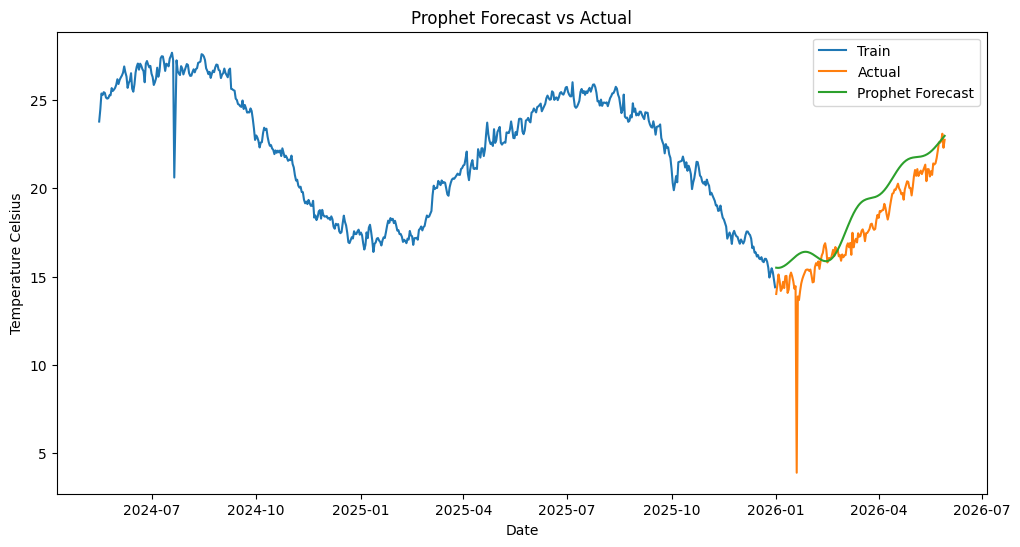

In [211]:
plt.figure(figsize=(12,6))

plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual')
plt.plot(test_prophet['ds'], pred_prophet, label='Prophet Forecast')

plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Temperature Celsius')
plt.show()

## Comparison of Time Series Models

In [212]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 594 to 742
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   date         149 non-null    datetime64[s]
 1   temperature  149 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 2.5 KB


MA-3    MAE:0.458  RMSE:1.060  R2:0.845
MA-7    MAE:0.520  RMSE:1.068  R2:0.843
ARIMA   MAE:2.374  RMSE:3.080  R2:-0.310
Prophet MAE:1.179  RMSE:1.596  R2:0.648


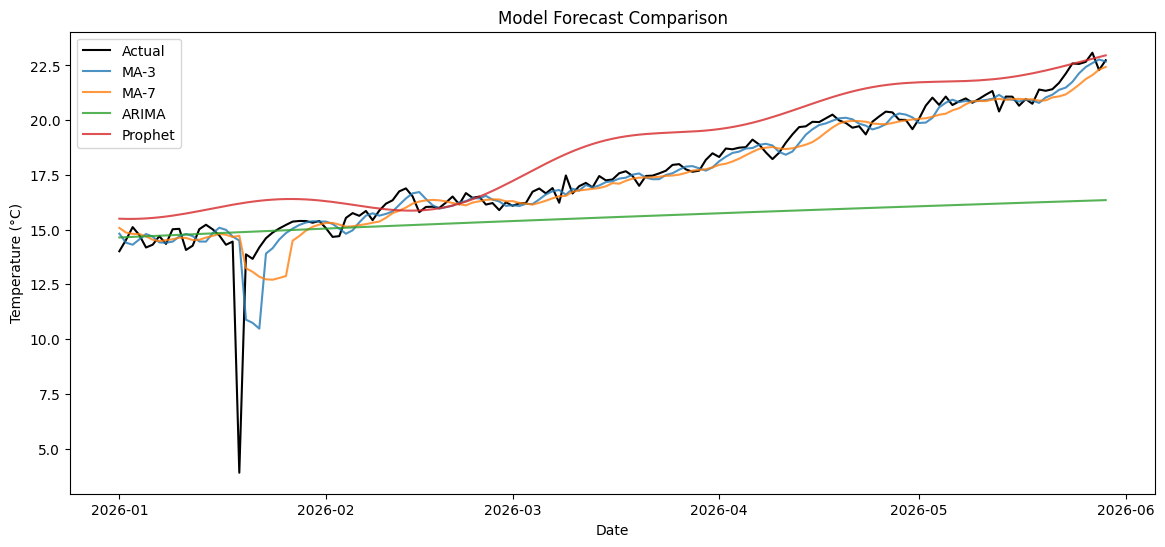

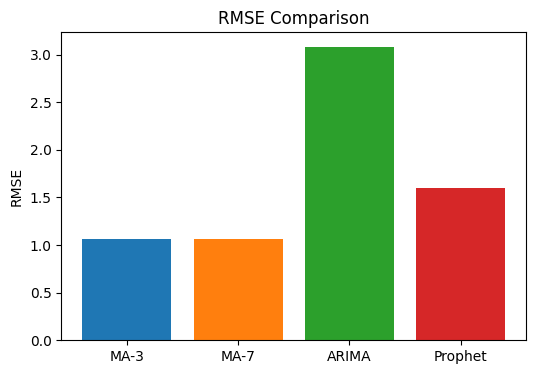

In [213]:
import numpy as np

# assemble predictions - MA-7 -> `pred_ma7`, MA-3 -> `pred_ma3`, ARIMA -> `forecast`, Prophet -> `y_pred`
pred_ma7_arr = np.asarray(pred_ma7)
pred_ma3_arr = np.asarray(pred_ma3)
pred_arima_arr = np.asarray(pred_arima)
pred_prophet_arr = np.asarray(pred_prophet)

y_true = test['temperature'].values

print(f'MA-3    MAE:{mae_ma3:.3f}  RMSE:{rmse_ma3:.3f}  R2:{r2_ma3:.3f}')
print(f'MA-7    MAE:{mae_ma7:.3f}  RMSE:{rmse_ma7:.3f}  R2:{r2_ma7:.3f}')
print(f'ARIMA   MAE:{mae_arima:.3f}  RMSE:{rmse_arima:.3f}  R2:{r2_arima:.3f}')
print(f'Prophet MAE:{mae_prophet:.3f}  RMSE:{rmse_prophet:.3f}  R2:{r2_prophet:.3f}')

# plot comparison
plt.figure(figsize=(14,6))
plt.plot(test['date'], y_true, label='Actual', color='k')
plt.plot(test['date'], pred_ma3_arr, label='MA-3', alpha=0.8)
plt.plot(test['date'], pred_ma7_arr, label='MA-7', alpha=0.8)
plt.plot(test['date'], pred_arima_arr, label='ARIMA', alpha=0.8)
plt.plot(test['date'], pred_prophet_arr, label='Prophet', alpha=0.8)
plt.legend()
plt.title('Model Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

# RMSE bar chart
models = ['MA-3','MA-7','ARIMA','Prophet']
rmses = [rmse_ma3, rmse_ma7, rmse_arima, rmse_prophet]
plt.figure(figsize=(6,4))
plt.bar(models, rmses, color=['C0','C1','C2','C3'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.show()

## Machine Learning Modelling

-  With weather features and lag features for target

In [214]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144229 entries, 0 to 144228
Data columns (total 86 columns):
 #   Column                                                      Non-Null Count   Dtype         
---  ------                                                      --------------   -----         
 0   latitude                                                    144229 non-null  float64       
 1   longitude                                                   144229 non-null  float64       
 2   last_updated                                                144229 non-null  datetime64[us]
 3   temperature_celsius                                         144229 non-null  float64       
 4   wind_mph                                                    144229 non-null  float64       
 5   pressure_mb                                                 144229 non-null  float64       
 6   precip_mm                                                   144229 non-null  float64       
 7   humidity              

### Creating lag features based on daily global average temperature

In [ ]:
df = df.sort_values('last_updated').copy()

daily_df = (
    df.groupby(df['last_updated'].dt.date)
      .agg({
          'temperature_celsius': 'mean',
          'day_of_year': 'first',
          'month_sin': 'first',
          'month_cos': 'first'
      })
      .reset_index()
)

daily_df = daily_df.rename(columns={
    'last_updated': 'date',
    'temperature_celsius': 'avg_temperature_celsius'
})

daily_df['date'] = pd.to_datetime(daily_df['date'])

daily_df['temp_lag_1'] = daily_df['avg_temperature_celsius'].shift(1)
daily_df['temp_lag_7'] = daily_df['avg_temperature_celsius'].shift(7)
daily_df['temp_lag_30'] = daily_df['avg_temperature_celsius'].shift(30)

daily_df['target_temp'] = daily_df['avg_temperature_celsius'].shift(-1)

daily_model_df = daily_df.dropna().copy()

features = [
    'avg_temperature_celsius',
    'temp_lag_1',
    'temp_lag_7',
    'temp_lag_30',
    'day_of_year',
    'month_sin',
    'month_cos'
]

MAE  : 0.394
RMSE : 1.072
R²   : 0.838


In [224]:
daily_model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 30 to 741
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype        
---  ------                   --------------  -----        
 0   date                     712 non-null    datetime64[s]
 1   avg_temperature_celsius  712 non-null    float64      
 2   day_of_year              712 non-null    int64        
 3   month_sin                712 non-null    float64      
 4   month_cos                712 non-null    float64      
 5   temp_lag_1               712 non-null    float64      
 6   temp_lag_7               712 non-null    float64      
 7   temp_lag_30              712 non-null    float64      
 8   target_temp              712 non-null    float64      
dtypes: datetime64[s](1), float64(7), int64(1)
memory usage: 50.2 KB


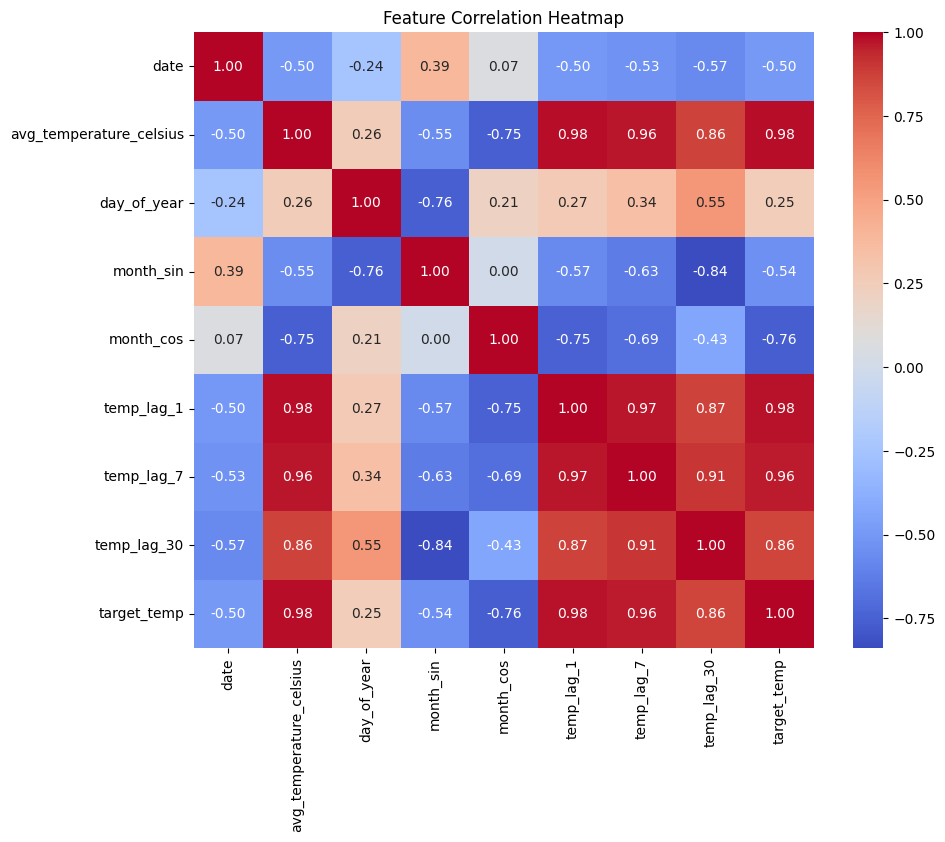

In [226]:
# heatmap of correlation
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(daily_model_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Linear Regression

####  All lag features

In [ ]:
# Modeling

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = daily_model_df[features]
y = daily_model_df['target_temp']

split_idx = int(len(daily_model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = daily_model_df['date'].iloc[:split_idx]
dates_test = daily_model_df['date'].iloc[split_idx:]

model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

model.fit(X_train, y_train)

y_pred_lag_all = model.predict(X_test)

mae_lag_all = mean_absolute_error(y_test, y_pred_lag_all)
rmse_lag_all = mean_squared_error(y_test, y_pred_lag_all) ** 0.5
r2_lag_all = r2_score(y_test, y_pred_lag_all)

print(f'MAE  : {mae_lag_all:.3f}')
print(f'RMSE : {rmse_lag_all:.3f}')
print(f'R²   : {r2_lag_all:.3f}')

MAE  : 0.394
RMSE : 1.072
R²   : 0.838


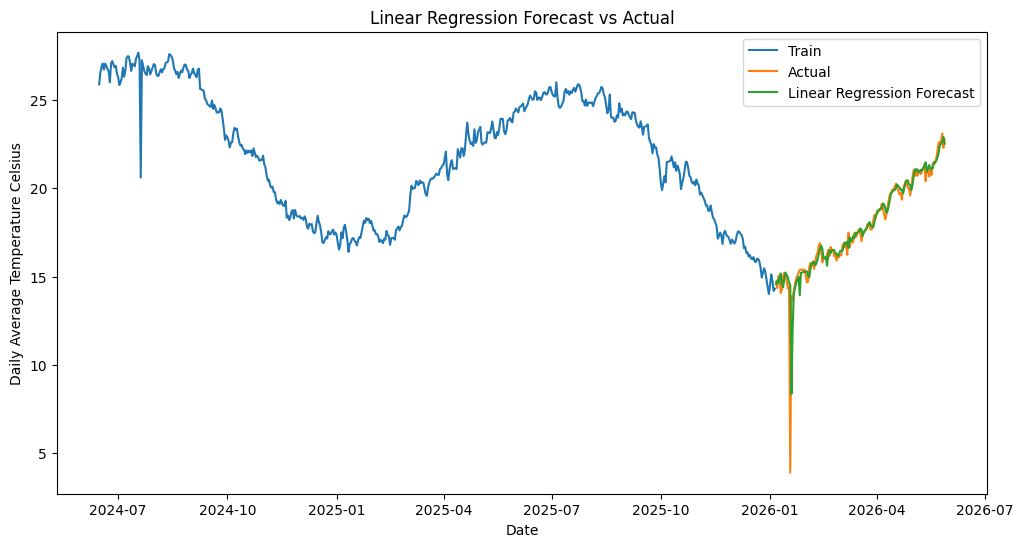

In [228]:
plt.figure(figsize=(12,6))

plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, y_pred, label='Linear Regression Forecast')

plt.legend()
plt.title('Linear Regression Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Average Temperature Celsius')
plt.show()

#### No temperature features

In [ ]:
# Modelling without any temperature features

daily_model_df['day_sin'] = np.sin(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

daily_model_df['day_cos'] = np.cos(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

features_no_temp = [
    'day_of_year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos'
]

# Modeling

X = daily_model_df[ features_no_temp ]
y = daily_model_df['target_temp']

split_idx = int(len(daily_model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = daily_model_df['date'].iloc[:split_idx]
dates_test = daily_model_df['date'].iloc[split_idx:]

model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

model.fit(X_train, y_train)

y_pred_no_temp = model.predict(X_test)

mae_no_temp = mean_absolute_error(y_test, y_pred_no_temp)
rmse_no_temp = mean_squared_error(y_test, y_pred_no_temp) ** 0.5
r2_no_temp = r2_score(y_test, y_pred_no_temp)

print(f'MAE  : {mae_no_temp:.3f}')
print(f'RMSE : {rmse_no_temp:.3f}')
print(f'R²   : {r2_no_temp:.3f}')

MAE  : 2.189
RMSE : 2.431
R²   : 0.167


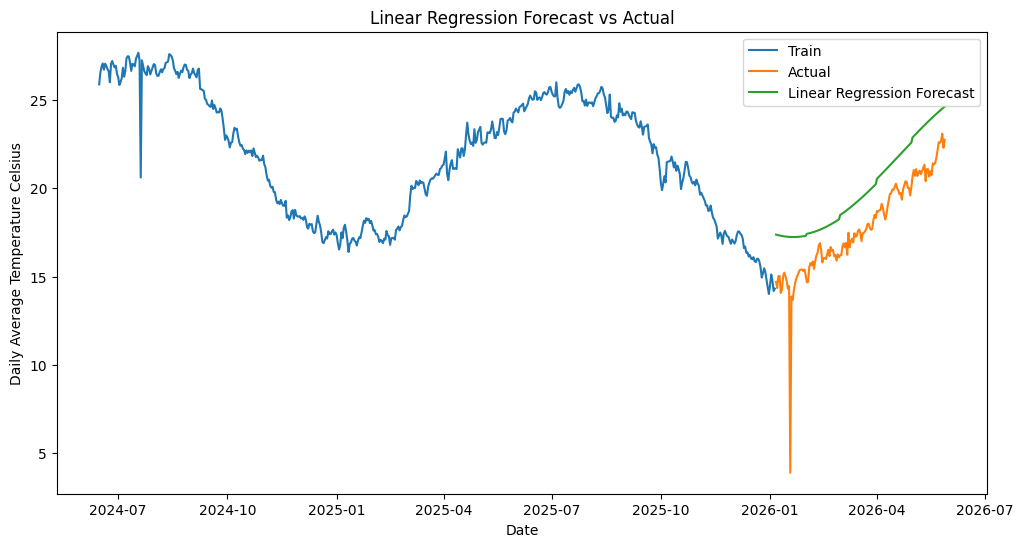

In [232]:
plt.figure(figsize=(12,6))

plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, y_pred, label='Linear Regression Forecast')

plt.legend()
plt.title('Linear Regression Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Average Temperature Celsius')
plt.show()

#### 30-day lag only

In [ ]:
# Modelling with 30 days ago temperature feature

daily_model_df['day_sin'] = np.sin(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

daily_model_df['day_cos'] = np.cos(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

features_no_temp = [
    'day_of_year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'temp_lag_30',
]

# Modeling

X = daily_model_df[ features_no_temp ]
y = daily_model_df['target_temp']

split_idx = int(len(daily_model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = daily_model_df['date'].iloc[:split_idx]
dates_test = daily_model_df['date'].iloc[split_idx:]

model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

model.fit(X_train, y_train)

y_pred_lag_30 = model.predict(X_test)

mae_lag_30 = mean_absolute_error(y_test, y_pred_lag_30)
rmse_lag_30 = mean_squared_error(y_test, y_pred_lag_30) ** 0.5
r2_lag_30 = r2_score(y_test, y_pred_lag_30)

print(f'MAE  : {mae_lag_30:.3f}')
print(f'RMSE : {rmse_lag_30:.3f}')
print(f'R²   : {r2_lag_30:.3f}')

MAE  : 1.119
RMSE : 1.628
R²   : 0.627


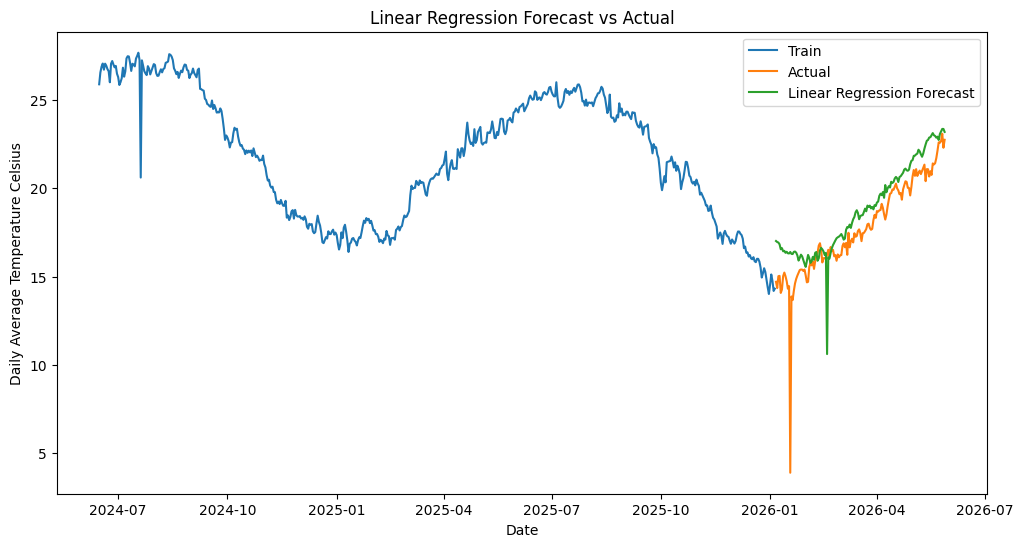

In [238]:
plt.figure(figsize=(12,6))

plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, y_pred, label='Linear Regression Forecast')

plt.legend()
plt.title('Linear Regression Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Average Temperature Celsius')
plt.show()

#### 7-day lag only

In [ ]:
# Modelling with 7 days ago temperature feature

daily_model_df['day_sin'] = np.sin(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

daily_model_df['day_cos'] = np.cos(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

features_no_temp = [
    'day_of_year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'temp_lag_7'
]

# Modeling

X = daily_model_df[ features_no_temp ]
y = daily_model_df['target_temp']

split_idx = int(len(daily_model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = daily_model_df['date'].iloc[:split_idx]
dates_test = daily_model_df['date'].iloc[split_idx:]

model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

model.fit(X_train, y_train)

y_pred_lag_7 = model.predict(X_test)

mae_lag_7 = mean_absolute_error(y_test, y_pred_lag_7)
rmse_lag_7 = mean_squared_error(y_test, y_pred_lag_7) ** 0.5
r2_lag_7 = r2_score(y_test, y_pred_lag_7)

print(f'MAE  : {mae_lag_7:.3f}')
print(f'RMSE : {rmse_lag_7:.3f}')
print(f'R²   : {r2_lag_7:.3f}')

MAE  : 0.784
RMSE : 1.362
R²   : 0.739


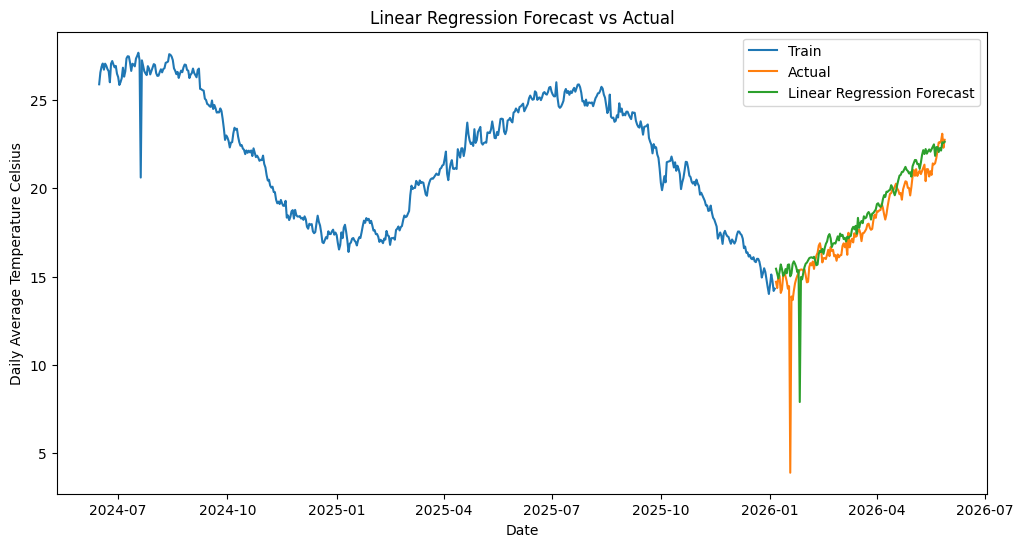

In [240]:
plt.figure(figsize=(12,6))

plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, y_pred, label='Linear Regression Forecast')

plt.legend()
plt.title('Linear Regression Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Average Temperature Celsius')
plt.show()

#### 1-day ago lag feature

In [ ]:
# Modelling with yesterday's temperature feature

daily_model_df['day_sin'] = np.sin(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

daily_model_df['day_cos'] = np.cos(
    2 * np.pi * daily_model_df['day_of_year'] / 365
)

features_no_temp = [
    'day_of_year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'avg_temperature_celsius'
]

# Modeling

X = daily_model_df[ features_no_temp ]
y = daily_model_df['target_temp']

split_idx = int(len(daily_model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = daily_model_df['date'].iloc[:split_idx]
dates_test = daily_model_df['date'].iloc[split_idx:]

model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

model.fit(X_train, y_train)

y_pred_lag_1 = model.predict(X_test)

mae_lag_1 = mean_absolute_error(y_test, y_pred_lag_1)
rmse_lag_1 = mean_squared_error(y_test, y_pred_lag_1) ** 0.5
r2_lag_1 = r2_score(y_test, y_pred_lag_1)

print(f'MAE  : {mae_lag_1:.3f}')
print(f'RMSE : {rmse_lag_1:.3f}')
print(f'R²   : {r2_lag_1:.3f}')

MAE  : 0.463
RMSE : 1.220
R²   : 0.790


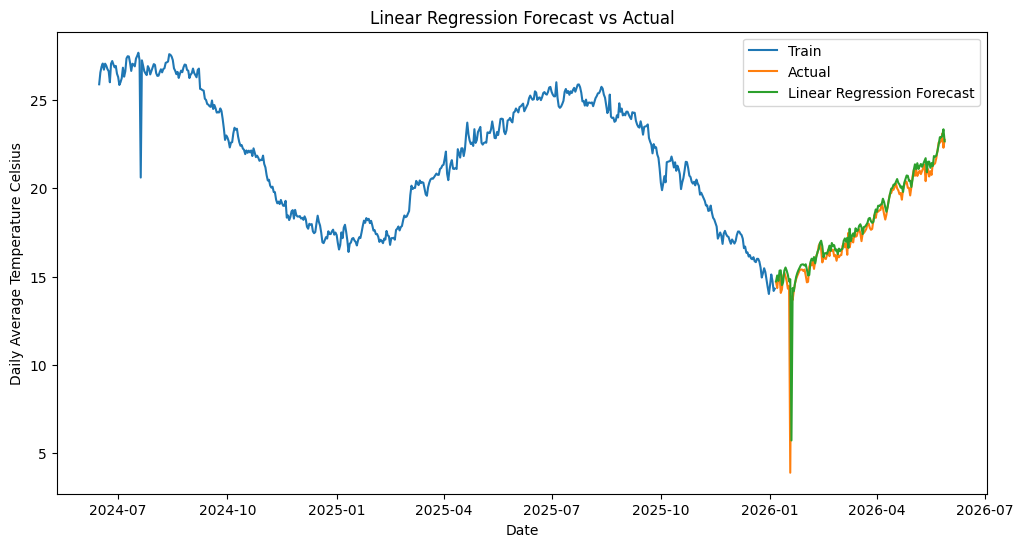

In [242]:
plt.figure(figsize=(12,6))

plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, y_pred, label='Linear Regression Forecast')

plt.legend()
plt.title('Linear Regression Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Daily Average Temperature Celsius')
plt.show()